# Fluid Mechanics — Chapter 1: Visualizations (v2)

Upgraded companion notebook with improved **physical correctness** and **visual clarity**.

| Problem | Visualization | Key Fixes |
|---------|---------------|-----------|
| 1.2 | Free surface of rotating fluid | Dynamic fill bounds; `gridspec` 3-D layout; colorbar |
| 1.3 | Rankine vortex profiles | Dynamic pressure fill; explicit y-limits; annotations |
| 1.7 | Streamlines & pollutant | Full-domain diverging colormap; full ±C streamlines; contrasting quiver |
| 1.8 | Streamlines vs pathlines | Alpha-layered streamline bundles; flow-equation annotations |


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 12,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 12,
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
print('Setup complete.')

Setup complete.


---
## Problem 1.2 — Free Surface of a Rotating Fluid

**Result:** Rotating fluid under gravity forms a paraboloid:
$$z = z_0 + \frac{\Omega^2}{2g}\,r^2, \qquad r^2 = x^2+y^2.$$

**Fixes applied (v2):**
- `fill_between` lower bound is now `z_wrong.min()` — dynamic, not hard-coded.
- 3-D panel placed via `gridspec` → `tight_layout` works correctly.
- Colorbar added to the 3-D panel.
- 'Wrong' Bernoulli label clarified with physical explanation.


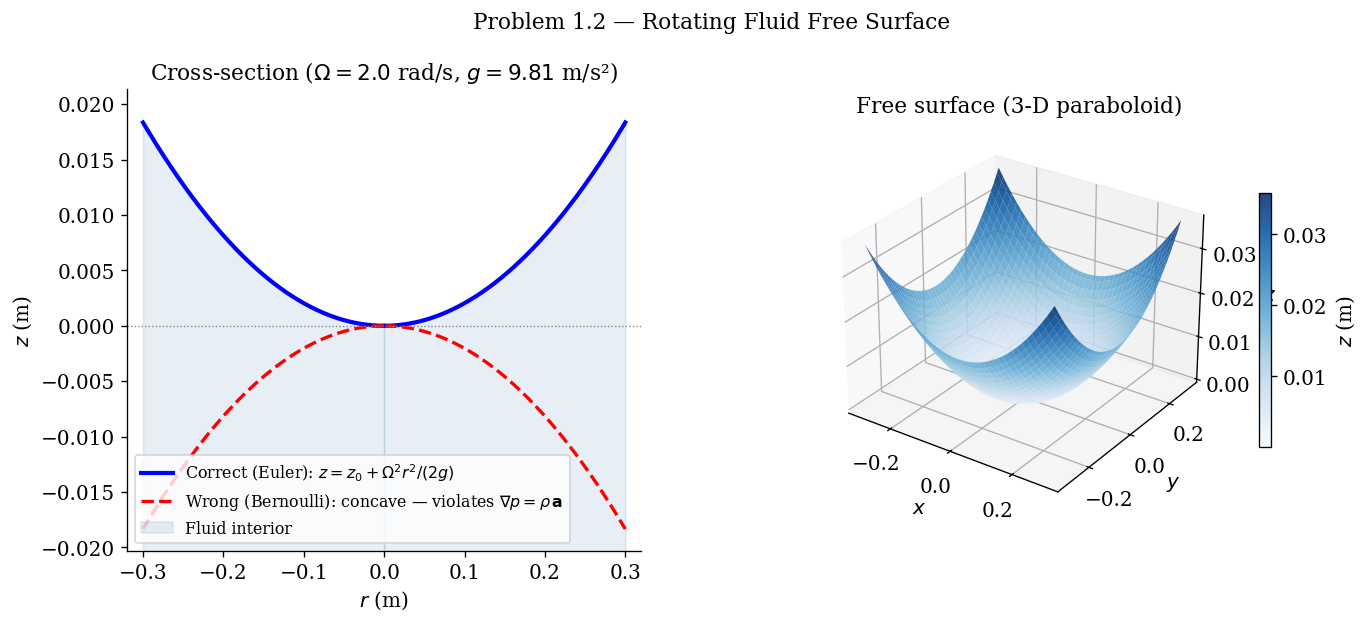

Saved: prob_1_2_free_surface.png


In [2]:
# ── Parameters ─────────────────────────────────────────────────────────────
Omega = 2.0   # angular velocity (rad/s)
g     = 9.81  # gravity (m/s²)
z0    = 0.0   # reference height at r = 0

r = np.linspace(0, 0.3, 300)

z_correct = z0 + (Omega**2 / (2*g)) * r**2   # Euler / centrifugal balance
z_wrong   = z0 - (Omega**2 / (2*g)) * r**2   # erroneous Bernoulli application

# ── Figure via gridspec so tight_layout works with the 3-D panel ──────────
fig = plt.figure(figsize=(13, 5.0))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Left: cross-section ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0])

ax.plot( r, z_correct, 'b-',  lw=2.5, label=r'Correct (Euler): $z=z_0+\Omega^2r^2/(2g)$')
ax.plot( r, z_wrong,   'r--', lw=2,   label=r'Wrong (Bernoulli): concave — violates $\nabla p = \rho\,\mathbf{a}$')
ax.plot(-r, z_correct, 'b-',  lw=2.5)
ax.plot(-r, z_wrong,   'r--', lw=2)
ax.axhline(z0, color='gray', lw=0.8, ls=':')

# Dynamic fill: uses actual minimum from the data
y_bottom = z_wrong.min() - 0.002
ax.fill_between( r, z_correct, y_bottom, alpha=0.13, color='steelblue', label='Fluid interior')
ax.fill_between(-r, z_correct, y_bottom, alpha=0.13, color='steelblue')

ax.set_xlabel(r'$r$ (m)')
ax.set_ylabel(r'$z$ (m)')
ax.set_title(fr'Cross-section ($\Omega={Omega}$ rad/s, $g={g}$ m/s²)')
ax.legend(fontsize=9.5)
ax.set_xlim(-0.32, 0.32)
ax.set_ylim(y_bottom, z_correct.max() + 0.003)

# ── Right: 3-D surface ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1], projection='3d')

x2 = np.linspace(-0.3, 0.3, 80)
X2, Y2 = np.meshgrid(x2, x2)
R2 = np.sqrt(X2**2 + Y2**2)
Z2 = z0 + (Omega**2 / (2*g)) * R2**2

surf = ax3.plot_surface(X2, Y2, Z2, cmap='Blues', alpha=0.88, linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax3, shrink=0.55, pad=0.08, label=r'$z$ (m)')
ax3.set_xlabel(r'$x$'); ax3.set_ylabel(r'$y$'); ax3.set_zlabel(r'$z$')
ax3.set_title('Free surface (3-D paraboloid)')
ax3.view_init(elev=28, azim=-55)

plt.suptitle('Problem 1.2 — Rotating Fluid Free Surface', fontsize=13, y=1.01)
plt.savefig('prob_1_2_free_surface.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: prob_1_2_free_surface.png')

---
## Problem 1.3 — Rankine Vortex: Velocity and Pressure Profiles

**Velocity:**
$$u_\theta = \begin{cases}\Omega r & r\leq a \\ \Omega a^2/r & r>a\end{cases}$$

**Pressure:**
$$p(r) = \begin{cases}p_\infty - \rho\Omega^2 a^2 + \tfrac{1}{2}\rho\Omega^2 r^2 & r\leq a \\
p_\infty - \rho\Omega^2 a^4/(2r^2) & r>a\end{cases}$$

**Fixes applied (v2):**
- Continuity assertion at $r = a$ added as a sanity check.
- Pressure `fill_between` lower bound uses `dp.min()` — dynamic.
- Both panels have explicit, matched y-limits.
- Annotations for $u_\theta^{\max}$ and $p_{\min}$ at $r=0$.
- Left margin widened so the long y-axis label is never clipped.


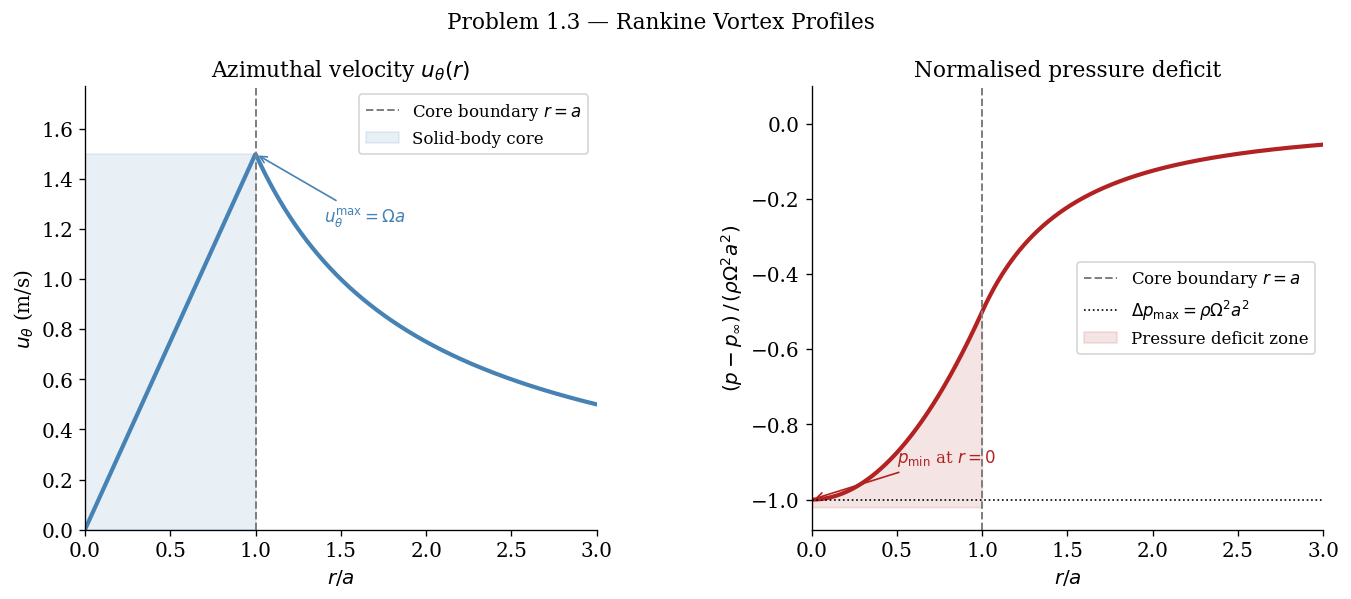

Saved: prob_1_3_rankine_vortex.png


In [3]:
Omega = 3.0    # rad/s
a     = 0.5    # core radius (m)
rho   = 1000.0 # water density (kg/m³)
p_inf = 101325 # Pa

r = np.linspace(0.001, 3*a, 1000)

# Velocity
u_theta = np.where(r <= a, Omega * r, Omega * a**2 / r)

# Pressure
p = np.where(
    r <= a,
    p_inf - rho*Omega**2*a**2 + 0.5*rho*Omega**2*r**2,
    p_inf - rho*Omega**2*a**4 / (2*r**2)
)
dp = (p - p_inf) / (rho * Omega**2 * a**2)   # normalised

# Sanity check: pressure must be continuous at r = a
assert np.isclose(
    p_inf - rho*Omega**2*a**2 + 0.5*rho*Omega**2*a**2,
    p_inf - rho*Omega**2*a**4 / (2*a**2)
), 'Pressure discontinuity at r=a — check formula!'

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
fig.subplots_adjust(left=0.10, right=0.96, wspace=0.42)

# ── Velocity profile ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(r/a, u_theta, color='steelblue', lw=2.5)
ax.axvline(1, color='gray', ls='--', lw=1.2, label=r'Core boundary $r=a$')
ax.fill_betweenx([0, Omega*a], 0, 1, alpha=0.12, color='steelblue', label='Solid-body core')
ax.annotate(r'$u_\theta^{\max} = \Omega a$',
            xy=(1, Omega*a), xytext=(1.4, Omega*a*0.82),
            arrowprops=dict(arrowstyle='->', color='steelblue'), fontsize=10, color='steelblue')
ax.set_xlabel(r'$r/a$')
ax.set_ylabel(r'$u_\theta$ (m/s)')
ax.set_title(r'Azimuthal velocity $u_\theta(r)$')
ax.legend(fontsize=10)
ax.set_xlim(0, 3)
ax.set_ylim(0, Omega*a * 1.18)

# ── Pressure profile ───────────────────────────────────────────────────────
ax = axes[1]
dp_min = dp.min()
ax.plot(r/a, dp, color='firebrick', lw=2.5)
ax.axvline(1, color='gray', ls='--', lw=1.2, label=r'Core boundary $r=a$')
ax.axhline(-1, color='k', ls=':', lw=1.0, label=r'$\Delta p_{\max} = \rho\Omega^2 a^2$')
# Dynamic lower fill bound
ax.fill_between(r/a, dp, dp_min - 0.02,
                where=(r <= a), alpha=0.12, color='firebrick', label='Pressure deficit zone')
ax.annotate(r'$p_{\min}$ at $r=0$',
            xy=(0, dp_min), xytext=(0.5, dp_min + 0.10),
            arrowprops=dict(arrowstyle='->', color='firebrick'), fontsize=10, color='firebrick')
ax.set_xlabel(r'$r/a$')
ax.set_ylabel(r'$(p - p_\infty)\,/\,(\rho\Omega^2 a^2)$')
ax.set_title('Normalised pressure deficit')
ax.legend(fontsize=10)
ax.set_xlim(0, 3)
ax.set_ylim(dp_min - 0.08, 0.10)

plt.suptitle('Problem 1.3 — Rankine Vortex Profiles', fontsize=13, y=1.01)
plt.savefig('prob_1_3_rankine_vortex.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: prob_1_3_rankine_vortex.png')

---
## Problem 1.7 — Streamlines and Pollutant Concentration

Flow: $u = \alpha x$, $v = -\alpha y$ (extensional / strain flow).

Streamlines: $xy = C$ (rectangular hyperbolae).

Pollutant: $c(x,y,t) = \beta\,x^2\,y\,e^{-\alpha t}$ — **defined on the full domain** (negative for $y < 0$).

**Fixes applied (v2):**
- Right panel: full domain, diverging colormap `RdBu_r` with `TwoSlopeNorm` (zero = white).
- Overlaid streamlines include **both** positive and negative $C$.
- quiver uses `'Oranges'` colormap to contrast with the blue contour lines.
- Streamline contour labels added (`clabel`).


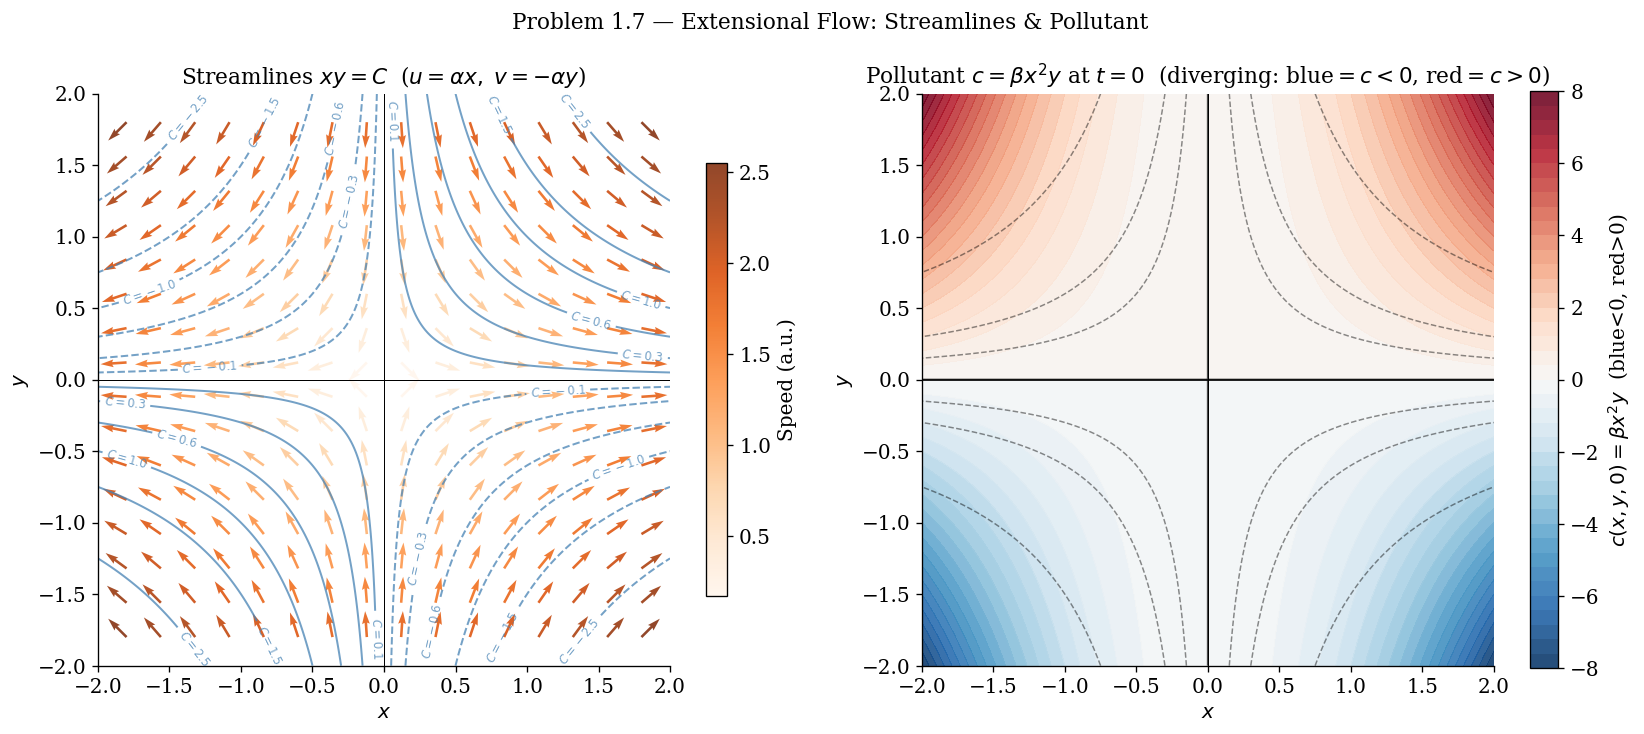

Saved: prob_1_7_streamlines.png


In [4]:
alpha = 1.0
beta  = 1.0

x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

# Velocity field (subsampled for quiver)
xq = np.linspace(-1.8, 1.8, 16)
yq = np.linspace(-1.8, 1.8, 16)
Xq, Yq = np.meshgrid(xq, yq)
U = alpha * Xq
V = -alpha * Yq
speed = np.sqrt(U**2 + V**2) + 1e-10

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

# ── Left: streamlines ──────────────────────────────────────────────────────
ax = axes[0]
C_vals = sorted([-2.5, -1.5, -1.0, -0.6, -0.3, -0.1,
                  0.1,  0.3,  0.6,  1.0,  1.5,  2.5])
cs = ax.contour(X, Y, X*Y, levels=C_vals,
                colors='steelblue', linewidths=1.2, alpha=0.75)
ax.clabel(cs, inline=True, fontsize=7, fmt=r'$C{=}%.1f$')

# Quiver: Oranges — contrasts clearly with steelblue streamlines
qv = ax.quiver(Xq, Yq, U/speed, V/speed, speed,
               cmap='Oranges', scale=22, width=0.0045, alpha=0.85)
plt.colorbar(qv, ax=ax, shrink=0.75, label='Speed (a.u.)')

ax.axhline(0, color='k', lw=0.6)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
ax.set_title(r'Streamlines $xy=C$  ($u=\alpha x,\;v=-\alpha y$)')
ax.set_aspect('equal'); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

# ── Right: pollutant — FULL domain, diverging colormap ────────────────────
ax = axes[1]
C_conc = beta * X**2 * Y          # full domain: negative for y < 0
c_abs  = np.abs(C_conc).max()

# TwoSlopeNorm: zero always maps to white centre of RdBu_r
norm = TwoSlopeNorm(vmin=-c_abs, vcenter=0, vmax=c_abs)
cf = ax.contourf(X, Y, C_conc, levels=40, cmap='RdBu_r', norm=norm, alpha=0.88)
plt.colorbar(cf, ax=ax, label=r'$c(x,y,0)=\beta x^2 y$  (blue<0, red>0)')

# Overlay streamlines — both positive AND negative C
C_overlay = sorted([-1.5, -0.6, -0.3, 0.3, 0.6, 1.5])
ax.contour(X, Y, X*Y, levels=C_overlay,
           colors='k', linewidths=0.9, alpha=0.45, linestyles='--')
ax.contour(X, Y, X*Y, levels=[0],
           colors='k', linewidths=1.2, alpha=0.7)   # xy = 0 (axes)

ax.axhline(0, color='k', lw=0.9)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
ax.set_title(r'Pollutant $c=\beta x^2 y$ at $t=0$  (diverging: blue$=c<0$, red$=c>0$)')
ax.set_aspect('equal'); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

plt.suptitle('Problem 1.7 — Extensional Flow: Streamlines & Pollutant', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('prob_1_7_streamlines.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: prob_1_7_streamlines.png')

---
## Problem 1.8 — Streamlines vs Pathlines in Unsteady Flow

Flow: $u = u_0$, $v = kt$.

**Streamlines** at time $t$:
$$\frac{dy}{dx} = \frac{v}{u} = \frac{kt}{u_0} \;\Rightarrow\; y = \frac{kt}{u_0}x + C \quad\text{(straight lines, slope grows with }t\text{)}$$

**Pathlines** (particle released from $(x_0,y_0)$ at $t=0$):
$$y - y_0 = \frac{k}{2u_0^2}(x-x_0)^2 \quad\text{(upward-opening parabola)}$$

**Fixes applied (v2):**
- Background streamlines drawn faint (`alpha=0.18`); one bold representative per time.
- Flow equations annotated directly on each panel.
- $t=0$ case explicitly visible as horizontal streamlines.


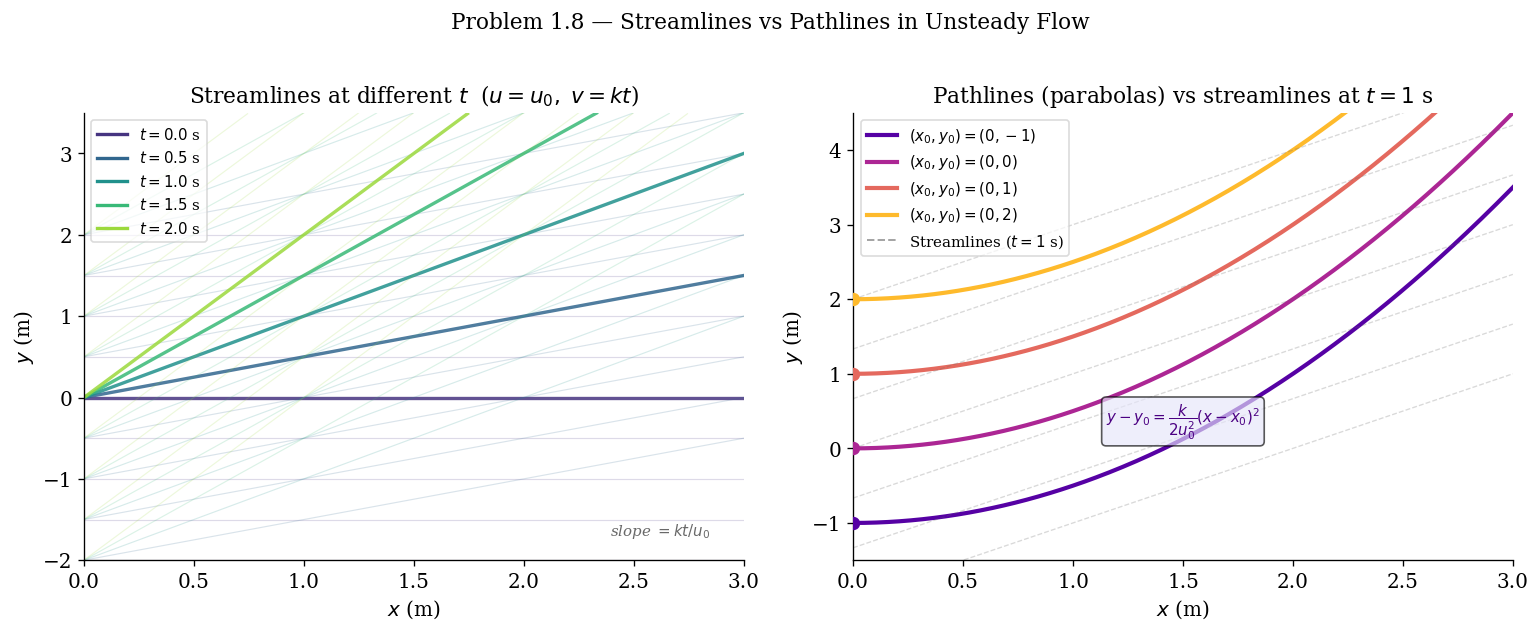

Saved: prob_1_8_streamlines_pathlines.png


In [5]:
u0 = 1.0   # m/s
k  = 1.0   # m/s²

x = np.linspace(0, 3, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# ── Left: streamlines at several times ────────────────────────────────────
ax = axes[0]
times    = [0.0, 0.5, 1.0, 1.5, 2.0]
colors   = plt.cm.viridis(np.linspace(0.15, 0.85, len(times)))
C_offsets = np.linspace(-2.0, 2.0, 9)

for t_val, col in zip(times, colors):
    slope = k * t_val / u0
    for C in C_offsets:
        y_sl = slope * x + C
        mask = (y_sl >= -2.0) & (y_sl <= 3.5)
        lw    = 2.0 if C == 0.0 else 0.7
        alpha = 0.85 if C == 0.0 else 0.18
        ax.plot(x[mask], y_sl[mask], color=col, lw=lw, alpha=alpha)
    ax.plot([], [], color=col, lw=2, label=fr'$t = {t_val}$ s')

ax.text(2.85, -1.7, r'slope $= kt/u_0$', fontsize=9, color='dimgray',
        ha='right', style='italic')

ax.set_xlabel(r'$x$ (m)'); ax.set_ylabel(r'$y$ (m)')
ax.set_title(r'Streamlines at different $t$  ($u=u_0,\;v=kt$)')
ax.legend(fontsize=9, loc='upper left', framealpha=0.7)
ax.set_xlim(0, 3); ax.set_ylim(-2, 3.5)

# ── Right: pathlines ───────────────────────────────────────────────────────
ax = axes[1]
start_points = [(0, -1.0), (0, 0.0), (0, 1.0), (0, 2.0)]
path_colors  = plt.cm.plasma(np.linspace(0.15, 0.85, len(start_points)))

for (x0, y0), col in zip(start_points, path_colors):
    y_path = y0 + (k / (2*u0**2)) * (x - x0)**2
    mask   = (y_path >= -1.5) & (y_path <= 5.0)
    ax.plot(x[mask], y_path[mask], color=col, lw=2.5,
            label=fr'$(x_0,y_0)=({x0:.0f},{y0:.0f})$')
    ax.plot(x0, y0, 'o', color=col, ms=7, zorder=5)

# Background streamlines at t = 1 (faint dashed)
slope_t1 = k * 1.0 / u0
for C in np.linspace(-2, 2, 7):
    y_sl = slope_t1 * x + C
    mask = (y_sl >= -1.5) & (y_sl <= 5.0)
    ax.plot(x[mask], y_sl[mask], 'dimgray', lw=0.8, ls='--', alpha=0.25)
ax.plot([], [], 'dimgray', lw=1.2, ls='--', alpha=0.6, label=r'Streamlines ($t=1$ s)')

ax.text(1.5, 0.35,
        r'$y - y_0 = \dfrac{k}{2u_0^2}(x-x_0)^2$',
        fontsize=9, color='indigo', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='lavender', alpha=0.65))

ax.set_xlabel(r'$x$ (m)'); ax.set_ylabel(r'$y$ (m)')
ax.set_title(r'Pathlines (parabolas) vs streamlines at $t=1$ s')
ax.legend(fontsize=9, loc='upper left', framealpha=0.7)
ax.set_xlim(0, 3); ax.set_ylim(-1.5, 4.5)

plt.suptitle('Problem 1.8 — Streamlines vs Pathlines in Unsteady Flow', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('prob_1_8_streamlines_pathlines.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: prob_1_8_streamlines_pathlines.png')

---
## Summary of saved figures

| File | Problem |
|------|---------|
| `prob_1_2_free_surface.png` | 1.2 Rotating fluid free surface |
| `prob_1_3_rankine_vortex.png` | 1.3 Rankine vortex profiles |
| `prob_1_7_streamlines.png` | 1.7 Extensional flow streamlines |
| `prob_1_8_streamlines_pathlines.png` | 1.8 Streamlines vs pathlines |

### Changes from v1

| # | Panel | Fix |
|---|-------|-----|
| 1.2 | Cross-section | `fill_between` 하한 동적화 (`z_wrong.min()`) |
| 1.2 | Layout | `gridspec` 사용 → `tight_layout` 오작동 해소 |
| 1.2 | 3-D | colorbar 추가 |
| 1.3 | Pressure | `fill_between` 하한 `dp.min()` 동적화 |
| 1.3 | Both | 명시적 y-limit; $u_\theta^{\max}$, $p_{\min}$ annotation |
| 1.3 | Both | continuity assertion 추가 |
| 1.7 | Concentration | 전체 도메인 + diverging colormap `RdBu_r` + `TwoSlopeNorm` |
| 1.7 | Concentration | 겹친 streamlines에 음수 $C$ 포함 |
| 1.7 | Streamlines | quiver → `Oranges` (파란 유선과 명확히 대비) |
| 1.7 | Streamlines | `clabel` 추가 |
| 1.8 | Streamlines | 배경 유선 `alpha=0.18`, 대표 유선 bold |
| 1.8 | Both | 수식 annotation 추가 |
